# KernelSynth

`KernelSynthGenerator` samples each series from a Gaussian-process prior whose covariance is a *random composition* of simple base kernels. For every series it draws `1..max_kernels` kernels from a fixed bank, folds them together with randomly chosen `+` and `*` operators, and draws one path from the resulting prior. Addition mixes behaviors (trend + seasonality); multiplication modulates them (locally periodic, amplitude-varying seasonality).

$$k = k_1 \star k_2 \star \dots \star k_n, \quad \star \in \{+, \times\}, \qquad f \sim \mathcal{GP}(0, k)$$

This adapts the KernelSynth recipe introduced for pretraining the Chronos forecasting models (Ansari et al. 2024, [*Chronos: Learning the Language of Time Series*](https://arxiv.org/abs/2403.07815)) and its Apache-2.0-licensed [reference implementation](https://github.com/amazon-science/chronos-forecasting/blob/main/scripts/kernel-synth.py). SynForecast makes the bank configurable, expresses seasonal periods in time steps on a normalized grid, and adds bounded retries, divergence guards, and optional standardization.

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast.generators import KernelSynthGenerator

## Generate a diverse pool

With the default bank, each series is a different kernel composition, so one call yields a varied pool. Lengths are fixed here to make the paths easy to compare; the composition is what varies.

In [ ]:
generator = KernelSynthGenerator(
    engine="polars",
    min_length=256,
    max_length=256,
    freq="h",
    seed=42,
)
ks_df = generator.generate(n_series=6)

ks_df.group_by("unique_id").agg(
    pl.len().alias("length"),
    pl.col("y").mean().round(3).alias("mean"),
    pl.col("y").std().round(3).alias("std"),
).sort("unique_id")

unique_id,length,mean,std
cat,u32,f64,f64
"""0""",256,0.0,1.002
"""1""",256,0.0,1.002
"""2""",256,-0.0,1.002
"""3""",256,0.0,1.002
"""4""",256,-0.0,1.002
"""5""",256,0.0,1.002


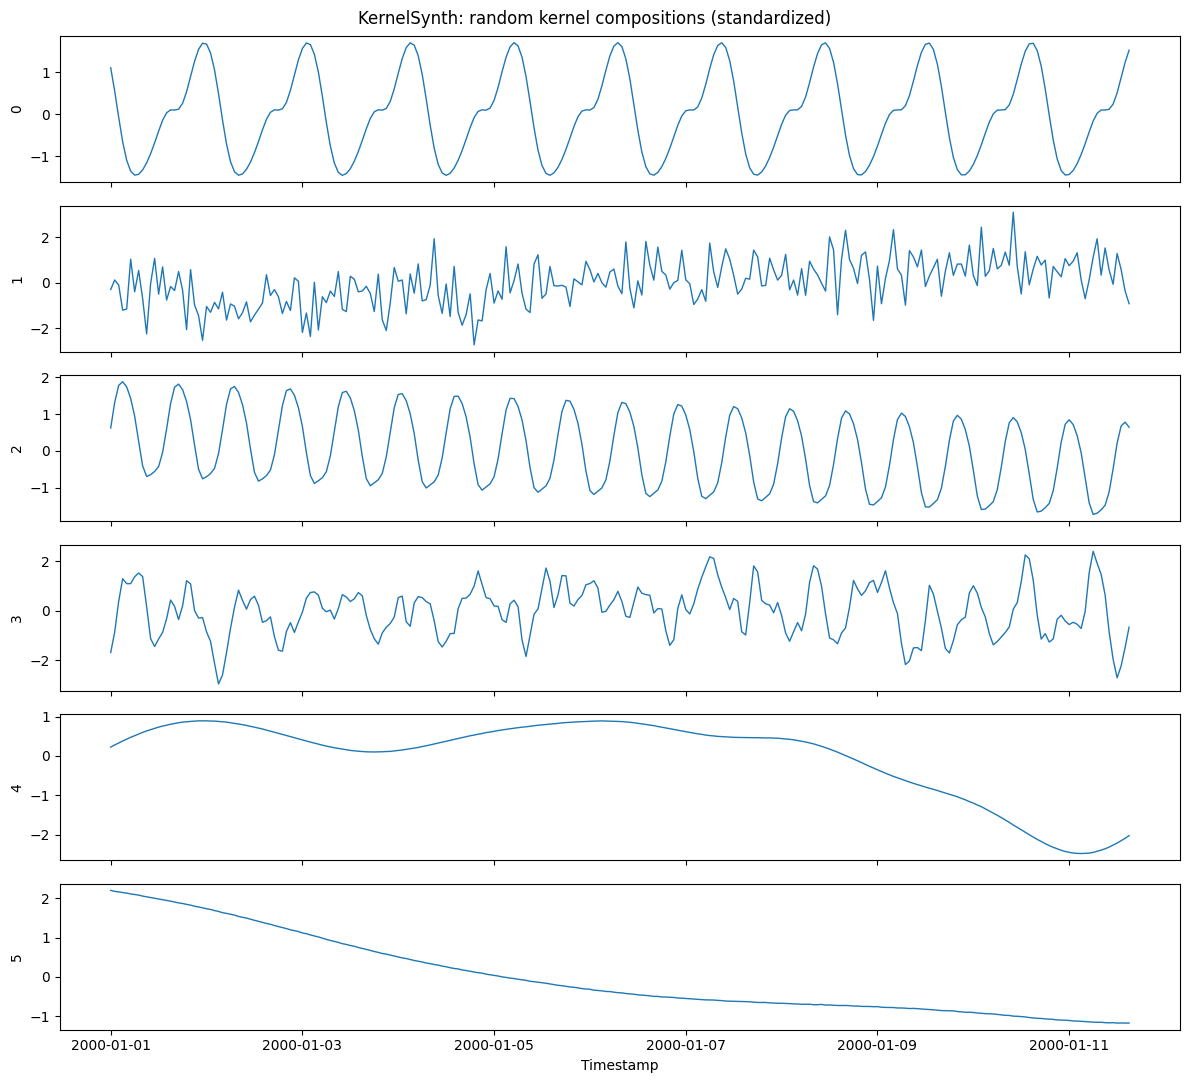

In [ ]:
fig, axes = plt.subplots(6, 1, figsize=(12, 11), sharex=True)
for ax, uid in zip(axes, ks_df["unique_id"].unique(maintain_order=True), strict=True):
    series = ks_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"], series["y"], linewidth=1)
    ax.set_ylabel(str(uid))
axes[-1].set_xlabel("Timestamp")
fig.suptitle("KernelSynth: random kernel compositions (standardized)")
plt.tight_layout()
plt.show()

## Constrain the kernel bank

Every kernel family is a list you can narrow or extend. To bias the pool toward a specific inductive structure, restrict the bank — here to a single daily period plus a smooth RBF trend, composed one or two at a time — so the draws concentrate on smooth, near-daily-periodic shapes.

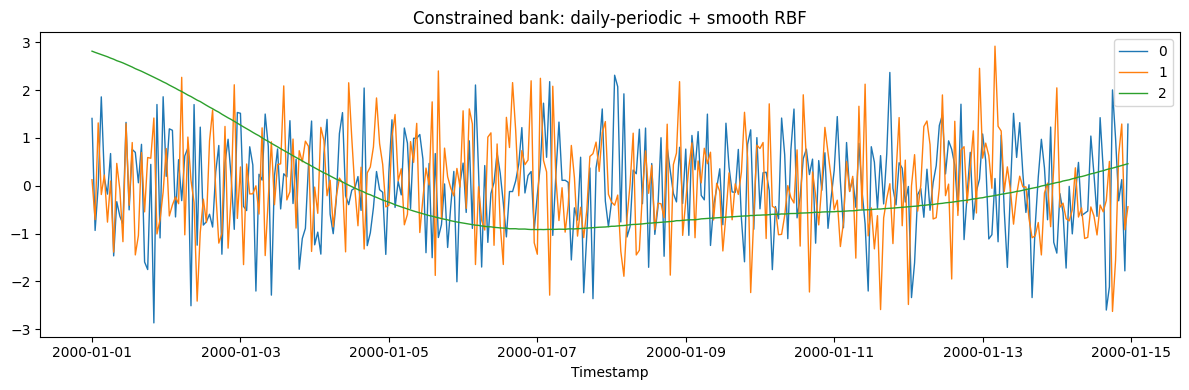

In [ ]:
periodic = KernelSynthGenerator(
    engine="polars",
    min_length=336,
    max_length=336,
    freq="h",
    max_kernels=2,
    seasonal_periods=[24.0],
    rbf_length_scales=[0.3],
    rational_quadratic_alphas=[],
    linear_sigmas=[],
    white_noise_levels=[0.05],
    include_constant=False,
    seed=7,
)
periodic_df = periodic.generate(n_series=3)

fig, ax = plt.subplots(figsize=(12, 4))
for uid in periodic_df["unique_id"].unique(maintain_order=True):
    s = periodic_df.filter(pl.col("unique_id") == uid)
    ax.plot(s["ds"], s["y"], linewidth=1, label=str(uid))
ax.set_title("Constrained bank: daily-periodic + smooth RBF")
ax.set_xlabel("Timestamp")
ax.legend()
plt.tight_layout()
plt.show()

## Use in a pretraining corpus

`standardize=True` (the default) rescales each series to zero mean and unit variance, so compositions that span very different natural scales stay comparable — the usual setting for a pretraining pool. Set `standardize=False` to keep the raw GP draws. Because `KernelSynthGenerator` is an ordinary generator, it composes with `SynSet`, `generate_series`, and the pattern-injection options like any other.

In [ ]:
raw = KernelSynthGenerator(
    engine="polars",
    min_length=128,
    max_length=128,
    freq="h",
    standardize=False,
    seed=0,
)
raw.generate(n_series=3).group_by("unique_id").agg(
    pl.col("y").std().round(3).alias("raw_std")
).sort("unique_id")

unique_id,raw_std
cat,f64
"""0""",0.612
"""1""",1.887
"""2""",0.312


::: {.callout-tip}
## Related generators

- [TSI](tsi) and [TCM](tcm) — the other pretraining generators (component composition and random causal graphs).
- [Gaussian process](../multivariate/gaussian_process) — a single fixed kernel rather than random compositions.

Full parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::